In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import time
from qforge.circuit import Qubit
from qforge.gates import CNOT, RY

torch.manual_seed(42)
num_samples = 40

# Dataset: 2 features, nhãn y = 1 nếu x0 + x1 > π
X = torch.rand(num_samples, 2) * 2 * math.pi
y = (X.sum(dim=1) > math.pi).float().view(-1, 1)

# Ansatz đồng bộ giữa các framework: 4 tham số, 2 lớp entangling
N_PARAMS = 4


def run_quantum_circuit(x_val, theta_val):
    """RY-encode | CNOT | RY(θ0,θ1) | CNOT | RY(θ2,θ3) | ⟨Z0⟩ ∈ [-1,1]."""
    wf = Qubit(2)
    RY(wf, 0, x_val[0])
    RY(wf, 1, x_val[1])
    CNOT(wf, 0, 1)
    RY(wf, 0, theta_val[0])
    RY(wf, 1, theta_val[1])
    CNOT(wf, 0, 1)
    RY(wf, 0, theta_val[2])
    RY(wf, 1, theta_val[3])
    probs = wf.probabilities()
    return float(probs[0] + probs[1] - probs[2] - probs[3])


class QforgeLayerOp(torch.autograd.Function):
    @staticmethod
    def forward(ctx, inputs, weights):
        ctx.save_for_backward(inputs, weights)
        return torch.tensor([run_quantum_circuit(inputs.tolist(), weights.tolist())],
                            dtype=torch.float32)

    @staticmethod
    def backward(ctx, grad_output):
        inputs, weights = ctx.saved_tensors
        x_val = inputs.tolist(); theta_val = weights.tolist()
        shift = math.pi / 2.0
        grads = []
        for i in range(len(theta_val)):
            tr = theta_val.copy(); tr[i] += shift
            tl = theta_val.copy(); tl[i] -= shift
            grads.append(0.5 * (run_quantum_circuit(x_val, tr) - run_quantum_circuit(x_val, tl)))
        return None, grad_output * torch.tensor(grads, dtype=torch.float32)


class QforgeQNN(nn.Module):
    """Hybrid: quantum layer (4 params) → classical Linear(1,1) → Sigmoid."""
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.rand(N_PARAMS) * 2 * math.pi)
        self.classical = nn.Linear(1, 1)

    def forward(self, x_batch):
        q = torch.stack([QforgeLayerOp.apply(x, self.theta) for x in x_batch])  # (N,1) ∈ [-1,1]
        return torch.sigmoid(self.classical(q))  # (N,1) ∈ [0,1]


model = QforgeQNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

epochs = 100
print("Qforge hybrid QNN (2 qubit, 4 quantum params + classical Linear)")

loss_history, acc_history, theta_history = [], [], []

start_total = time.time()
for epoch in range(epochs):
    start_epoch = time.time()
    optimizer.zero_grad()
    probs_pred = model(X)
    loss = criterion(probs_pred, y)
    loss.backward()
    optimizer.step()

    epoch_time = time.time() - start_epoch
    acc = ((probs_pred > 0.5).float() == y).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)
    theta_history.append(model.theta.detach().clone().tolist())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {loss.item():.4f} | "
              f"Acc: {acc*100:5.1f}% | Time/epoch: {epoch_time:.2f}s")

total_time = time.time() - start_total
print(f"Tổng chạy Qforge: {total_time:.2f}s - TB: {total_time/epochs:.2f}s/epoch")
model.theta


Qforge hybrid QNN (2 qubit, 4 quantum params + classical Linear)
Epoch 01/100 | Loss: 0.3179 | Acc:  42.5% | Time/epoch: 0.00s
Epoch 05/100 | Loss: 0.2172 | Acc:  72.5% | Time/epoch: 0.00s
Epoch 10/100 | Loss: 0.1471 | Acc:  90.0% | Time/epoch: 0.00s
Epoch 15/100 | Loss: 0.1067 | Acc:  90.0% | Time/epoch: 0.00s
Epoch 20/100 | Loss: 0.0872 | Acc:  90.0% | Time/epoch: 0.00s
Epoch 25/100 | Loss: 0.0775 | Acc:  90.0% | Time/epoch: 0.00s
Epoch 30/100 | Loss: 0.0728 | Acc:  90.0% | Time/epoch: 0.00s
Epoch 35/100 | Loss: 0.0695 | Acc:  90.0% | Time/epoch: 0.00s
Epoch 40/100 | Loss: 0.0663 | Acc:  90.0% | Time/epoch: 0.00s
Epoch 45/100 | Loss: 0.0639 | Acc:  90.0% | Time/epoch: 0.00s
Epoch 50/100 | Loss: 0.0611 | Acc:  92.5% | Time/epoch: 0.00s
Epoch 55/100 | Loss: 0.0579 | Acc:  95.0% | Time/epoch: 0.00s
Epoch 60/100 | Loss: 0.0554 | Acc:  92.5% | Time/epoch: 0.00s
Epoch 65/100 | Loss: 0.0520 | Acc:  92.5% | Time/epoch: 0.00s
Epoch 70/100 | Loss: 0.0464 | Acc:  95.0% | Time/epoch: 0.00s
Epoch

Parameter containing:
tensor([1.3239e+00, 3.5776e-03, 7.5012e+00, 1.8717e+00], requires_grad=True)

In [3]:
# ============================================================
# PennyLane — cùng ansatz 4 params + classical Linear(1,1) + Sigmoid
# ============================================================
results = {
    "Qforge": {"loss": loss_history, "acc": acc_history, "time": total_time},
}

try:
    import pennylane as qml

    dev = qml.device("default.qubit", wires=2)

    @qml.qnode(dev, interface="torch", diff_method="parameter-shift")
    def pl_circuit(inputs, weights):
        qml.RY(inputs[0], wires=0)
        qml.RY(inputs[1], wires=1)
        qml.CNOT(wires=[0, 1])
        qml.RY(weights[0], wires=0)
        qml.RY(weights[1], wires=1)
        qml.CNOT(wires=[0, 1])
        qml.RY(weights[2], wires=0)
        qml.RY(weights[3], wires=1)
        return qml.expval(qml.PauliZ(0))

    class PennyLaneQNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.theta = nn.Parameter(torch.rand(N_PARAMS) * 2 * math.pi)
            self.classical = nn.Linear(1, 1)

        def forward(self, x_batch):
            q = torch.stack([pl_circuit(x, self.theta) for x in x_batch]).view(-1, 1).float()
            return torch.sigmoid(self.classical(q))

    pl_model = PennyLaneQNN()
    pl_opt = optim.Adam(pl_model.parameters(), lr=0.1)

    pl_loss_hist, pl_acc_hist = [], []
    t0 = time.time()
    for epoch in range(epochs):
        pl_opt.zero_grad()
        probs_pred = pl_model(X)
        loss = criterion(probs_pred, y)
        loss.backward()
        pl_opt.step()
        pl_loss_hist.append(loss.item())
        pl_acc_hist.append(((probs_pred > 0.5).float() == y).float().mean().item())
    pl_time = time.time() - t0
    print(f"PennyLane: loss={pl_loss_hist[-1]:.4f}  acc={pl_acc_hist[-1]*100:.1f}%  time={pl_time:.2f}s")
    results["PennyLane"] = {"loss": pl_loss_hist, "acc": pl_acc_hist, "time": pl_time}
except ImportError as e:
    print(f"PennyLane không có sẵn: {e}")


PennyLane: loss=0.0573  acc=90.0%  time=15.46s


In [4]:
# ============================================================
# Qiskit — cùng ansatz 4 params + classical Linear(1,1) + Sigmoid
# ============================================================
try:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector

    def qiskit_expval(x_val, theta_val):
        qc = QuantumCircuit(2)
        qc.ry(x_val[0], 0)
        qc.ry(x_val[1], 1)
        qc.cx(0, 1)
        qc.ry(theta_val[0], 0)
        qc.ry(theta_val[1], 1)
        qc.cx(0, 1)
        qc.ry(theta_val[2], 0)
        qc.ry(theta_val[3], 1)
        sv = Statevector.from_instruction(qc)
        probs = sv.probabilities()  # Qiskit little-endian: qubit 0 là LSB
        return float((probs[0] + probs[2]) - (probs[1] + probs[3]))

    class QiskitLayerOp(torch.autograd.Function):
        @staticmethod
        def forward(ctx, inputs, weights):
            ctx.save_for_backward(inputs, weights)
            return torch.tensor([qiskit_expval(inputs.tolist(), weights.tolist())],
                                dtype=torch.float32)

        @staticmethod
        def backward(ctx, grad_output):
            inputs, weights = ctx.saved_tensors
            x_val = inputs.tolist(); theta_val = weights.tolist()
            shift = math.pi / 2.0
            grads = []
            for i in range(len(theta_val)):
                tr = theta_val.copy(); tr[i] += shift
                tl = theta_val.copy(); tl[i] -= shift
                grads.append(0.5 * (qiskit_expval(x_val, tr) - qiskit_expval(x_val, tl)))
            return None, grad_output * torch.tensor(grads, dtype=torch.float32)

    class QiskitQNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.theta = nn.Parameter(torch.rand(N_PARAMS) * 2 * math.pi)
            self.classical = nn.Linear(1, 1)

        def forward(self, x_batch):
            q = torch.stack([QiskitLayerOp.apply(x, self.theta) for x in x_batch])
            return torch.sigmoid(self.classical(q))

    qk_model = QiskitQNN()
    qk_opt = optim.Adam(qk_model.parameters(), lr=0.1)

    qk_loss_hist, qk_acc_hist = [], []
    t0 = time.time()
    for epoch in range(epochs):
        qk_opt.zero_grad()
        probs_pred = qk_model(X)
        loss = criterion(probs_pred, y)
        loss.backward()
        qk_opt.step()
        qk_loss_hist.append(loss.item())
        qk_acc_hist.append(((probs_pred > 0.5).float() == y).float().mean().item())
    qk_time = time.time() - t0
    print(f"Qiskit:    loss={qk_loss_hist[-1]:.4f}  acc={qk_acc_hist[-1]*100:.1f}%  time={qk_time:.2f}s")
    results["Qiskit"] = {"loss": qk_loss_hist, "acc": qk_acc_hist, "time": qk_time}
except ImportError as e:
    print(f"Qiskit không có sẵn: {e}")


Qiskit:    loss=0.0585  acc=90.0%  time=6.20s


In [5]:
# ============================================================
# Merlin (LightOn — merlinquantum.ai) — photonic QuantumLayer cho PyTorch
# API dùng factory .simple(input_size, output_size)
# ============================================================
try:
    import merlin as ML
    import torch.nn as nn
    import time
    import torch.optim as optim

    class MerlinQNN(nn.Module):
        def __init__(self):
            super().__init__()
            # Lớp lượng tử photonic: 2 đầu vào, 1 đầu ra (xác suất-like trong [0,1])
            self.qlayer = ML.QuantumLayer.simple(input_size=2, output_size=1)

        def forward(self, x_batch):
            out = self.qlayer(x_batch)
            if out.dim() == 1:
                out = out.view(-1, 1)
            return out  # giả định đã ∈ [0, 1]

    m_model = MerlinQNN()
    m_opt = optim.Adam(m_model.parameters(), lr=0.1)

    m_loss_hist, m_acc_hist = [], []
    t0 = time.time()
    for epoch in range(epochs):
        m_opt.zero_grad()
        probs_pred = m_model(X)
        # Nếu output nằm ngoài [0,1] thì chuẩn hoá qua sigmoid
        if probs_pred.min() < 0 or probs_pred.max() > 1:
            probs_pred = torch.sigmoid(probs_pred)
        loss = criterion(probs_pred, y)
        loss.backward()
        m_opt.step()
        m_loss_hist.append(loss.item())
        m_acc_hist.append(((probs_pred > 0.5).float() == y).float().mean().item())
    m_time = time.time() - t0
    print(f"Merlin:    loss={m_loss_hist[-1]:.4f}  acc={m_acc_hist[-1]*100:.1f}%  time={m_time:.2f}s")
    results["Merlin"] = {"loss": m_loss_hist, "acc": m_acc_hist, "time": m_time}
except ImportError as e:
    print(f"Merlin không có sẵn: {e}  —  pip install merlinquantum")
except Exception as e:
    print(f"Merlin lỗi runtime: {type(e).__name__}: {e}")


Merlin:    loss=0.1185  acc=90.0%  time=0.25s


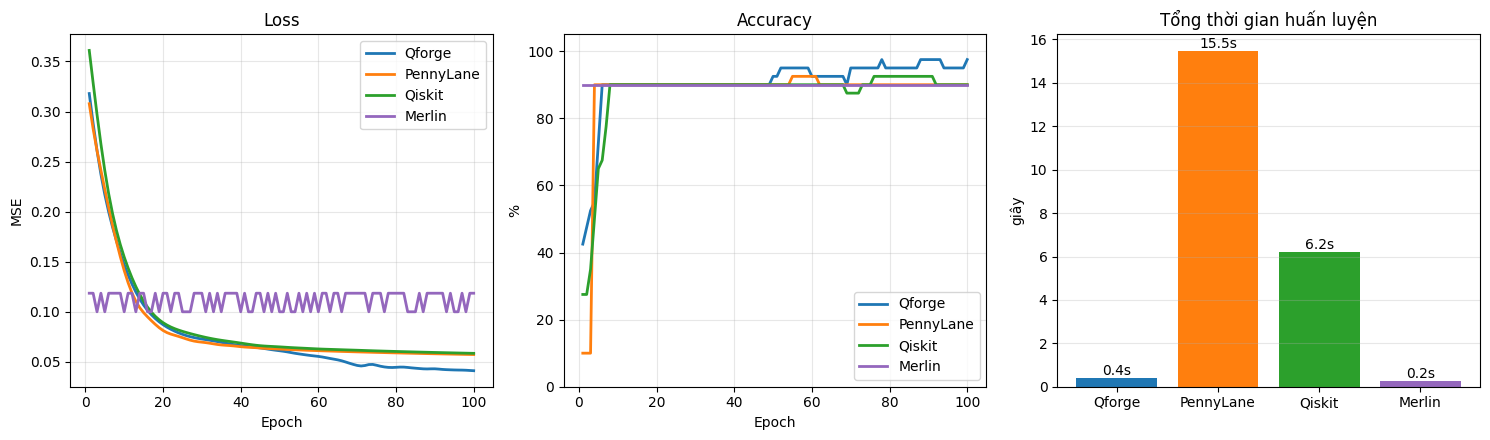


=== Tổng kết ===
Qforge      final_loss=0.0412  final_acc= 97.5%  time=0.38s
PennyLane   final_loss=0.0573  final_acc= 90.0%  time=15.46s
Qiskit      final_loss=0.0585  final_acc= 90.0%  time=6.20s
Merlin      final_loss=0.1185  final_acc= 90.0%  time=0.25s


In [6]:
# ============================================================
# So sánh các framework
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
colors = {"Qforge": "#1f77b4", "PennyLane": "#ff7f0e", "Qiskit": "#2ca02c", "Merlin": "#9467bd"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for name, r in results.items():
    ep = np.arange(1, len(r["loss"]) + 1)
    axes[0].plot(ep, r["loss"], label=name, color=colors.get(name), lw=2)
    axes[1].plot(ep, np.array(r["acc"]) * 100, label=name, color=colors.get(name), lw=2)

axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE")
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("%")
axes[1].set_ylim(0, 105); axes[1].grid(alpha=0.3); axes[1].legend()

names = list(results.keys())
times = [results[n]["time"] for n in names]
bars = axes[2].bar(names, times, color=[colors.get(n, "gray") for n in names])
axes[2].set_title("Tổng thời gian huấn luyện"); axes[2].set_ylabel("giây")
for b, t in zip(bars, times):
    axes[2].text(b.get_x() + b.get_width() / 2, b.get_height(), f"{t:.1f}s",
                 ha="center", va="bottom")
axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\n=== Tổng kết ===")
for n, r in results.items():
    print(f"{n:10s}  final_loss={r['loss'][-1]:.4f}  final_acc={r['acc'][-1]*100:5.1f}%  time={r['time']:.2f}s")
